# **Homework \#1**
### Author: Skyler Ruiter
### Date: September 10, 2025
### Course: Deep Learning Systems (ENGR-E 533)

---

#### Setup:

Load the needed modules and setup / verify the device torch detects

In [191]:
import torch
from torch.utils.data import DataLoader
import torchvision
import numpy as np
import time
import matplotlib.pyplot as plt

print(torch.cuda.is_available())
device=torch.device('cuda')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(device)

True
cuda


Download the MNIST training and testing datasets. Normalize them and turn them into tensors. Then use the DataLoader to batch the data and optimize the workflow with pinned memory, prefetching, and batch sizes. Verify the shape of the data.

In [192]:
mnist_train = torchvision.datasets.MNIST('mnist',
                                         train=True,
                                         download=True,
                                         transform=torchvision.transforms.Compose([
                                             torchvision.transforms.ToTensor(),
                                             torchvision.transforms.Normalize((0.1307,), (0.3081,))
                                         ]))
mnist_test = torchvision.datasets.MNIST('mnist',
                                        train=False,
                                        download=True,
                                        transform=torchvision.transforms.Compose([
                                            torchvision.transforms.ToTensor(),
                                            torchvision.transforms.Normalize((0.1307,), (0.3081,))
                                        ]))

train_dataloader = DataLoader(mnist_train, batch_size=256, num_workers=4, pin_memory=True, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=256, num_workers=4, pin_memory=True, shuffle=True)

for X, y in test_dataloader:
    print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")
    break

Shape of X: torch.Size([256, 1, 28, 28]), Shape of y: torch.Size([256])


---

#### Question 1: Softmax MNIST Classification

Created a simple torch NN model for with only the softmax regression. 

Uses cross entropy loss and SGD to optimize.

Also defines the methods for training and testing NNs

In [193]:
class SoftmaxRegression(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.linear = torch.nn.Linear(28*28, 10)
    
  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear(x)
    return logits

model = SoftmaxRegression().to(device)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

def train(dataloader, model, loss_fn, optimizer):
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    
    # prediction error
    pred = model(X)
    loss = loss_fn(pred, y)
    
    # backprop
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()
  test_loss, correct = 0, 0
  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= size
  return correct


Function to visualize the weight matrices to see the features being learned

In [194]:
def plot_weights(model, epoch):
  weights = model.linear.weight.detach().cpu().numpy()
  fig, axes = plt.subplots(1, 10, figsize=(15, 2))
  for i in range(10):
    axes[i].imshow(weights[i].reshape(28, 28), cmap='seismic')
    axes[i].axis('off')
  plt.suptitle(f'Weights after epoch {epoch}')
  plt.show()

Trains the softmax regression network that doesn't learn a latent space. Uses 200 epochs and stores the test accuracy at each epoch. 

Displays the weights after 20 and 200 epochs. Then plots the test accuracy over the epochs.

* The weights after 20 epochs show some structure but are quite noisy. After 200 the weights gain a slight amount more definition.

* The plot shows that the model quickly converges to ~92% accuracy by 100 epochs and stays there.

Epoch 1
Epoch 11


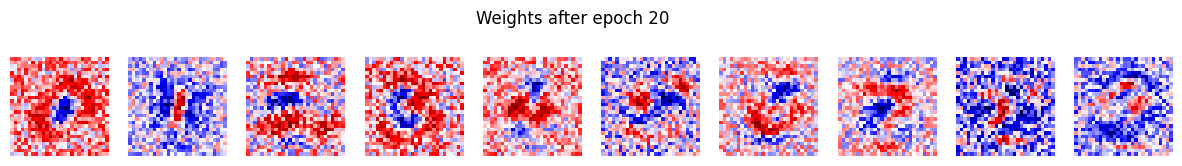

Epoch 21
Epoch 31
Epoch 41
Epoch 51
Epoch 61
Epoch 71
Epoch 81
Epoch 91
Epoch 101
Epoch 111
Epoch 121
Epoch 131
Epoch 141
Epoch 151
Epoch 161
Epoch 171
Epoch 181
Epoch 191


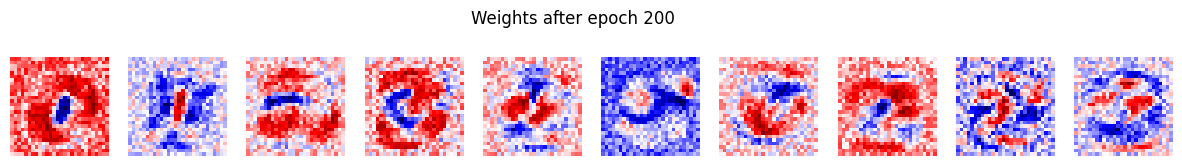

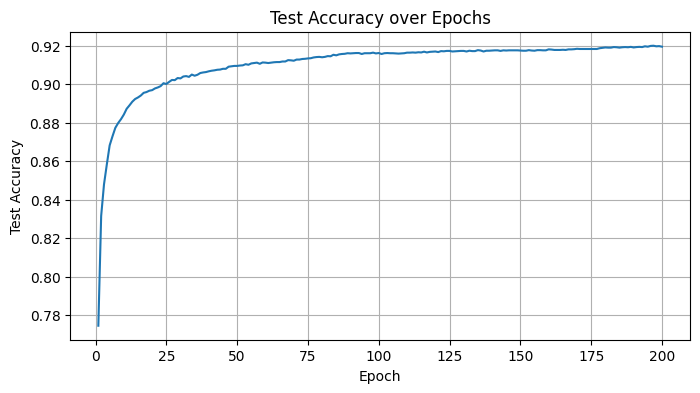

In [195]:
test_accuracies = []

epochs = 200
for t in range(epochs):
  if t % 10 == 0:
    print(f"Epoch {t+1}")
  train(train_dataloader, model, loss_fn, optimizer)
  acc = test(test_dataloader, model, loss_fn)
  test_accuracies.append(acc)
  
  if t+1 == 20 or t+1 == 200:
    plot_weights(model, t+1)

plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), test_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy over Epochs")
plt.grid(True)
plt.show()

---

#### Question 2: Autoencoders

In [196]:
test_accuracies_naive = []
test_accuracies_sparse = []

Class for the Naive Autoencoder implementation. Uses a hidden dimension of 100 and a single hidden layer. 

Uses Sigmoid as the non-linear activation function.

Also defines methods for testing and training the Autoencoder.

In [197]:
class AutoencoderNaive(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.encoder = torch.nn.Sequential(
      torch.nn.Linear(784, 100),
      torch.nn.Sigmoid()
    )
    self.decoder = torch.nn.Linear(100, 784)
  def forward(self, x):
    x = self.flatten(x)
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded
  
def train_AE(dataloader, model, loss_fn, optimizer):
  model.train()
  for batch, (X, _) in enumerate(dataloader):
    X = X.to(device)
    
    X_reconstruct = model(X)
    loss = loss_fn(X_reconstruct, X.view(X.size(0), -1))
    
    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  
def test_AE(dataloader, model, loss_fn):
  model.eval()
  test_loss = 0
  num_batches = len(dataloader)
  size = len(dataloader.dataset)
  with torch.no_grad():
    for X, _ in dataloader:
      X = X.to(device)      
      X_reconstruct = model(X)
      test_loss += loss_fn(X_reconstruct, X.view(X.size(0), -1)).item()
  test_loss /= num_batches
  # print(f"Test loss: {test_loss:.4f}")
  return test_loss

Found a useful sparse autoencoder implementation online, which I adopted here.

We use the same Sigmoid non-linear activation function and model structure, but use the KL divergence with a sparsity target and sparsity lambda to encourage the model to learn more robust and meaningful features in the latent space.

Also adopts their training method.

In [198]:
# https://github.com/IParraMartin/Sparse-Autoencoder/blob/main/sae.py
class AutoEncoderSparse(torch.nn.Module):
  def __init__(self, sparsity_target=0.2, sparsity_lambda=0.1):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.encoder = torch.nn.Sequential(
      torch.nn.Linear(784, 100),
      torch.nn.Sigmoid()
    )
    self.decoder = torch.nn.Linear(100, 784)
    self.sparsity_target = sparsity_target
    self.sparsity_lambda = sparsity_lambda
  def forward(self, x):
    x = self.flatten(x)
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return encoded, decoded
  def sparsity_penalty(self, encoded):
    rho_hat = torch.mean(encoded, dim=0)
    rho = self.sparsity_target
    epsilon = 1e-8
    rho_hat = torch.clamp(rho_hat, min=epsilon, max=1 - epsilon)
    kl_divergence = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
    sparsity_penalty = torch.sum(kl_divergence)
    return self.sparsity_lambda * sparsity_penalty
  def loss_function(self, x_hat, x, encoded):
    mse_loss = torch.nn.functional.mse_loss(x_hat, x)
    sparsity_loss = self.sparsity_penalty(encoded)
    return mse_loss + sparsity_loss
  
def train_AE_sparse(data_loader, model, optimizer, n_epochs):
  for epoch in range(n_epochs):
    total_loss = 0
    for data, _ in data_loader:
      data = data.view(data.size(0), -1).to(device)
      optimizer.zero_grad()
      encoded, decoded = model(data)
      loss = model.loss_function(decoded, data, encoded)
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()
      total_loss += loss.item()
    if epoch % 10 == 0:
      print(f"Epoch {epoch+1}, Loss: {total_loss/len(data_loader):.4f}")

  sample_data, _ = next(iter(data_loader))
  sample_data = sample_data.view(sample_data.size(0), -1).to(device)
  with torch.no_grad():
    activations, _ = model(sample_data)
  return activations.cpu().numpy(), sample_data.cpu().numpy()

Training the Naive and Sparse Autoencoders

* uses 200 epochs for training
* base loss uses MSE (w/ sparisty adding sparsity regularization)
* tried to use SGD but found Adam worked far better for autoencoders

In [199]:
naive_model = AutoencoderNaive().to(device)
naive_loss_fn = torch.nn.MSELoss()
naive_optimizer = torch.optim.Adam(naive_model.parameters(), lr=1e-3)

naive_losses = []
epochs = 200

In [200]:
sparse_losses = []

sparse_model = AutoEncoderSparse().to(device)
sparse_loss_fn = sparse_model.loss_function
sparse_optimizer = torch.optim.Adam(sparse_model.parameters(), lr=1e-2)

In [201]:
print("Training Naive Autoencoder Beginning")
for t in range(epochs):
  train_AE(train_dataloader, naive_model, naive_loss_fn, naive_optimizer)
  loss = test_AE(test_dataloader, naive_model, naive_loss_fn)
  naive_losses.append(loss)
  if t % 10 == 0:
    print(f"Epoch {t+1}, Loss: {loss:.4f}")
print("Training Naive Autoencoder Complete")

Training Naive Autoencoder Beginning
Epoch 1, Loss: 0.2934
Epoch 11, Loss: 0.0777
Epoch 21, Loss: 0.0676
Epoch 31, Loss: 0.0655
Epoch 41, Loss: 0.0646
Epoch 51, Loss: 0.0637
Epoch 61, Loss: 0.0630
Epoch 71, Loss: 0.0630
Epoch 81, Loss: 0.0625
Epoch 91, Loss: 0.0622
Epoch 101, Loss: 0.0624
Epoch 111, Loss: 0.0621
Epoch 121, Loss: 0.0618
Epoch 131, Loss: 0.0616
Epoch 141, Loss: 0.0630
Epoch 151, Loss: 0.0614
Epoch 161, Loss: 0.0617
Epoch 171, Loss: 0.0613
Epoch 181, Loss: 0.0610
Epoch 191, Loss: 0.0610
Training Naive Autoencoder Complete


In [202]:
print("Training Sparse Autoencoder Beginning")
activations, samples = train_AE_sparse(train_dataloader, sparse_model, sparse_optimizer, epochs)
print("Training Sparse Autoencoder Complete")

Training Sparse Autoencoder Beginning
Epoch 1, Loss: 0.3981
Epoch 11, Loss: 0.1850
Epoch 21, Loss: 0.1843
Epoch 31, Loss: 0.1855
Epoch 41, Loss: 0.1862
Epoch 51, Loss: 0.1877
Epoch 61, Loss: 0.1876
Epoch 71, Loss: 0.1879
Epoch 81, Loss: 0.1877
Epoch 91, Loss: 0.1899
Epoch 101, Loss: 0.1889
Epoch 111, Loss: 0.1898
Epoch 121, Loss: 0.1905
Epoch 131, Loss: 0.1898
Epoch 141, Loss: 0.1892
Epoch 151, Loss: 0.1907
Epoch 161, Loss: 0.1897
Epoch 171, Loss: 0.1902
Epoch 181, Loss: 0.1885
Epoch 191, Loss: 0.1896
Training Sparse Autoencoder Complete


Method to display the weights, reconstructions, and latent space magnitude of an autoencoder

In [203]:
def print_ae_results(model, dataloader, model_type="naive"):
    # Smaller figure and yellow-blue palette
    plt.figure(figsize=(8, 6))
    plt.suptitle("Learned Feature Templates", fontsize=16)

    # Get encoder weights (first layer)
    weights = model.encoder[0].weight.data.cpu().numpy()

    # Plot 25 templates in a 5x5 grid
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.imshow(weights[i].reshape(28, 28), cmap='YlGnBu')
        plt.axis('off')
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

    # Reconstructed images (smaller)
    plt.figure(figsize=(10, 8))
    plt.suptitle("Reconstructed Images", fontsize=16)

    data_iter = iter(dataloader)
    images, _ = next(data_iter)
    images_subset = images[:25].to(device)

    with torch.no_grad():
        if model_type == "sparse":
            _, reconstructions = model(images_subset)
        else:
            reconstructions = model(images_subset)

    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.imshow(reconstructions[i].cpu().view(28, 28), cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

    # Hidden unit activations (unchanged, but smaller)
    plt.figure(figsize=(8, 6))
    plt.suptitle("Hidden Unit Activations (Latent Space)", fontsize=16)

    data_iter = iter(dataloader)
    images, _ = next(data_iter)
    images_subset = images[:150].to(device)

    with torch.no_grad():
        if model_type == "sparse":
            activations, _ = model(images_subset)
        else:
            activations = model.encoder(model.flatten(images_subset))

    act_slice = activations[:150, :100].cpu().numpy()
    plt.imshow(act_slice, cmap='YlGnBu', aspect='auto')
    plt.colorbar(label="Activation Value")
    plt.xlabel("Hidden Unit Index")
    plt.ylabel("Sample Index")
    plt.title(f"Hidden Activations Heatmap ({model_type.capitalize()} Autoencoder)")
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

### Naive Autoencoder Results

The templates learned by the naive autoencoder are not easy to interpret, and appear to capture abstract pixel patterns rather than meaningful features like edges.

The reconstruction looked great after the full training process. And the latent space was very noisy, with little pattern or structure.

### Sparse Autoencoder Results

The templates learned by the sparse autoencoder on the other hand are much more robust looking. They appear to model the edges of the numbers or specific elements within the images. The reconstruction is a bit more blurry in comparison, but that is due to the sparisty constraint providing another element to optimize.

The latent space is more structured and very sparse to utilize the learned features from the encoder. 

Naive Autoencoder Results:


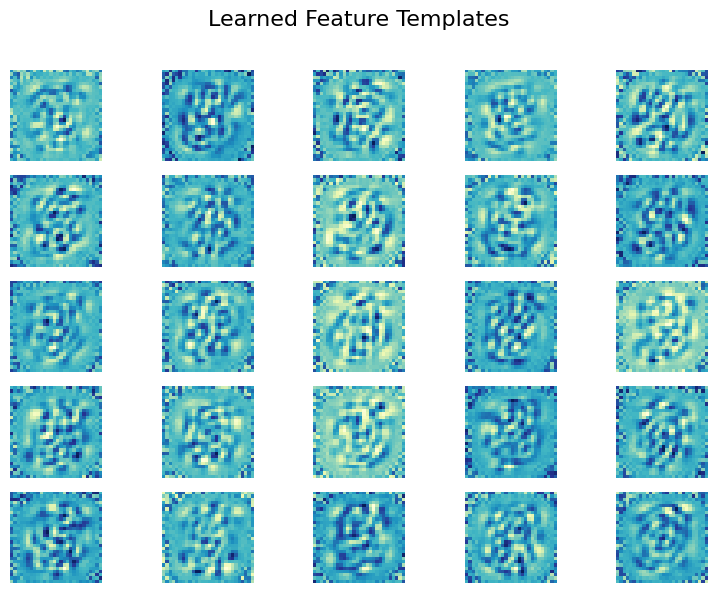

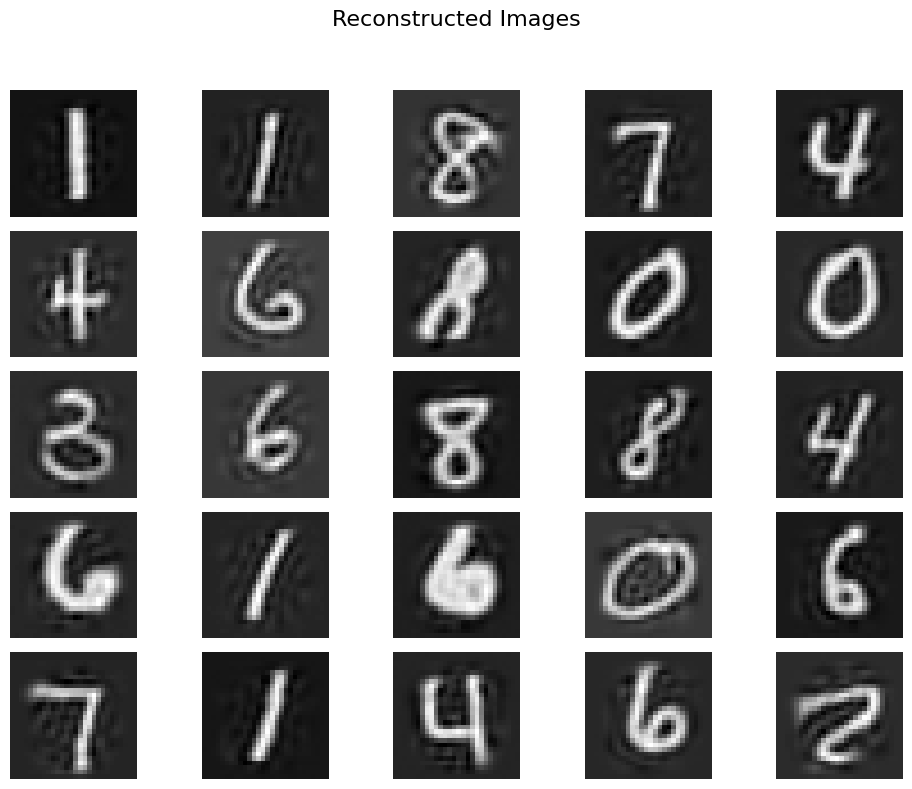

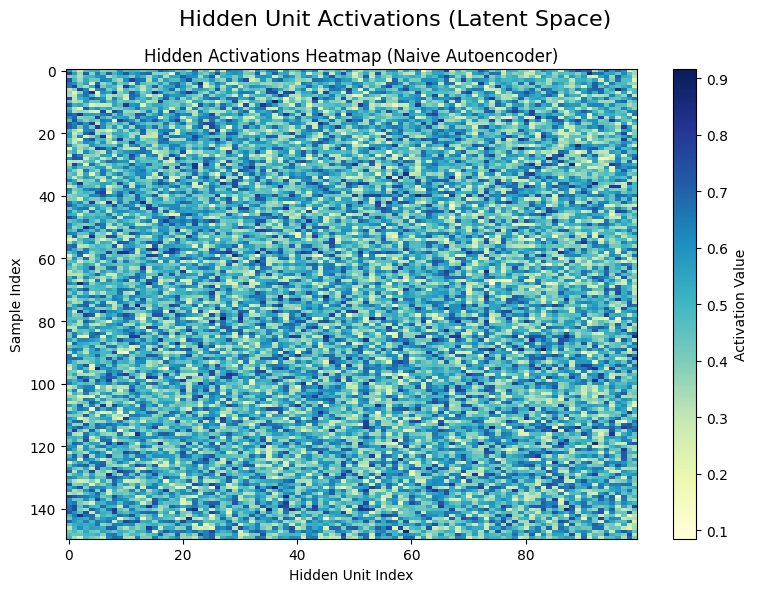


Sparse Autoencoder Results:


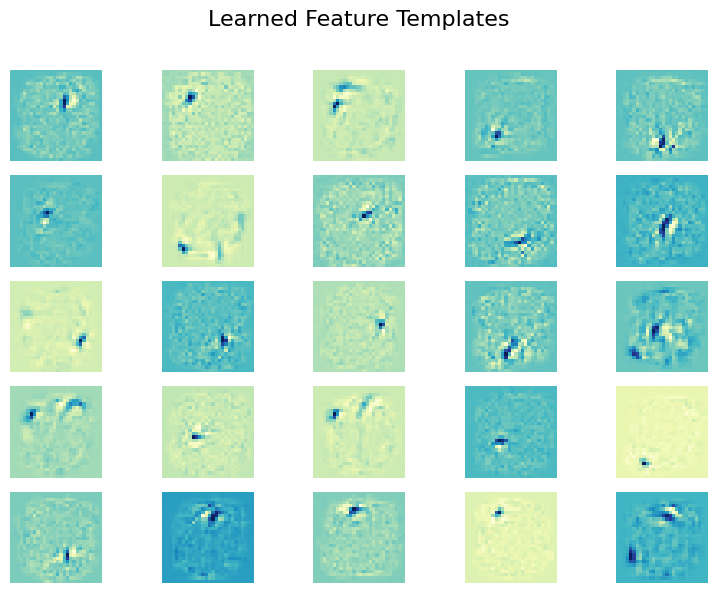

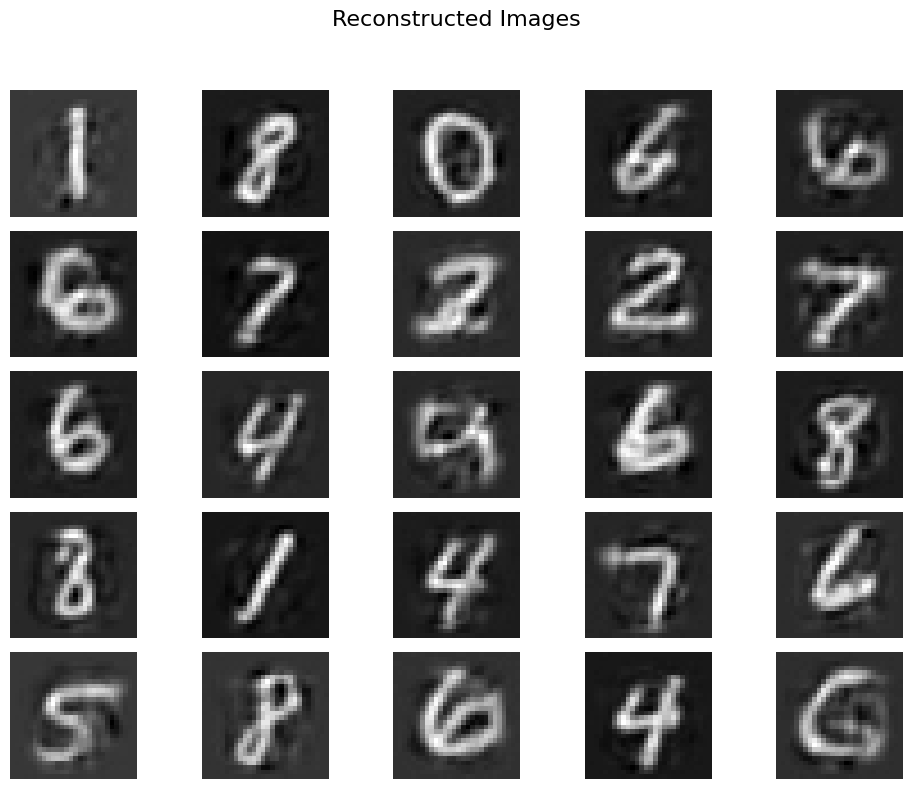

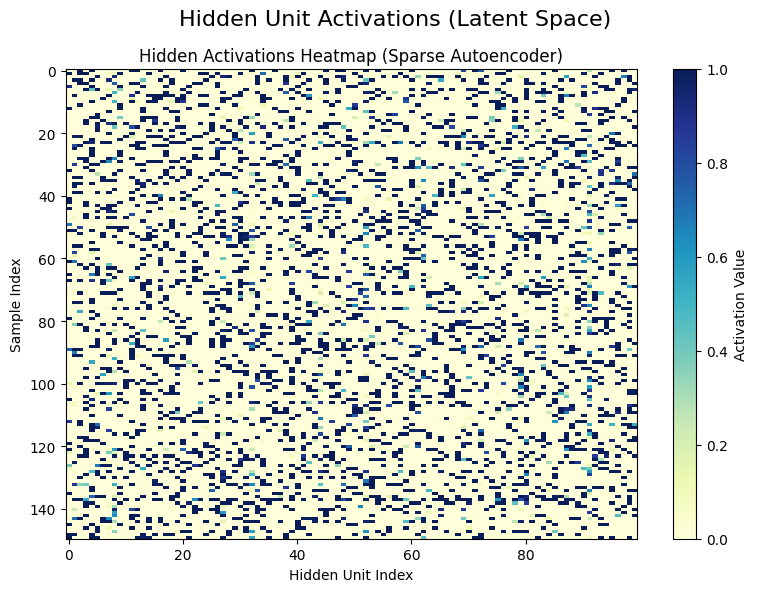

In [204]:
# Visualize both autoencoders
print("Naive Autoencoder Results:")
print_ae_results(naive_model, test_dataloader, "naive")

print("\nSparse Autoencoder Results:")
print_ae_results(sparse_model, test_dataloader, "sparse")

#### Note:

**Since the graph in question 3 is a superset of the graph in question 2, see the plot in the next question to avoid code duplication.**

---

#### Question 3: A Shallow NN

A simple shallow NN model with 1 hidden layer of size 100. Uses ReLU activation, cross entropy loss, and SGD optimizer.

In [205]:
class ShallowNN(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.linear = torch.nn.Sequential(
      torch.nn.Linear(28*28, 100),
      torch.nn.ReLU(),
      torch.nn.Linear(100, 10)
    )
    
  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear(x)
    return logits

model = ShallowNN().to(device)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

Altered the architecture of the above class to support providing pre-trained weights which don't need to be updated during training. 

Uses Sigmoid as the non-linear activation, and optimizes using Adam. SGD was tried, but resulted in poor training results.

In [206]:
class FixedFirstLayerNN(torch.nn.Module):
  def __init__(self, encoder_linear):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.encoder = torch.nn.Linear(28*28, 100)
    self.encoder.weight = torch.nn.Parameter(encoder_linear.weight.data.clone(), requires_grad=False)
    self.encoder.bias = torch.nn.Parameter(encoder_linear.bias.data.clone(), requires_grad=False)
    self.activation = torch.nn.Sigmoid()
    self.fc2 = torch.nn.Linear(100, 10)

  def forward(self, x):
    x = self.flatten(x)
    x = self.encoder(x)
    x = self.activation(x)
    x = self.fc2(x)
    return x
    
naive_encoder_linear = naive_model.encoder[0]
sparse_encoder_linear = sparse_model.encoder[0]

fixed_naive_nn = FixedFirstLayerNN(naive_encoder_linear).to(device)
fixed_sparse_nn = FixedFirstLayerNN(sparse_encoder_linear).to(device)

optimizer_naive = torch.optim.Adam(fixed_naive_nn.fc2.parameters(), lr=1e-3)
optimizer_sparse = torch.optim.Adam(fixed_sparse_nn.fc2.parameters(), lr=1e-3)

Trains the simple NN, and the fixed weight autoencoder based NNs (sparse and naive) with 200 epochs and saves the test accuracy for each epoch

In [207]:
test_accuracies_NN = []
test_accuracies_naive = []
test_accuracies_sparse = []

epochs = 200
for t in range(epochs):
  if t % 10 == 0:
    print(f"Epoch {t+1}")
  train(train_dataloader, model, loss_fn, optimizer)
  acc = test(test_dataloader, model, loss_fn)
  test_accuracies_NN.append(acc)

  train(train_dataloader, fixed_naive_nn, loss_fn, optimizer_naive)
  acc_naive = test(test_dataloader, fixed_naive_nn, loss_fn)
  test_accuracies_naive.append(acc_naive)
  
  train(train_dataloader, fixed_sparse_nn, loss_fn, optimizer_sparse)
  acc_sparse = test(test_dataloader, fixed_sparse_nn, loss_fn)
  test_accuracies_sparse.append(acc_sparse)

Epoch 1
Epoch 11
Epoch 21
Epoch 31
Epoch 41
Epoch 51
Epoch 61
Epoch 71
Epoch 81
Epoch 91
Epoch 101
Epoch 111
Epoch 121
Epoch 131
Epoch 141
Epoch 151
Epoch 161
Epoch 171
Epoch 181
Epoch 191


Replicates the figure in M02-S14: with the simple NN coming out on top, followed by the sparse NN, the softmax regression, and finally the naive NN. 

This shows the effectiveness of using a more structured latent space in the sparse autoencoder, as well as the costs of learning poor representations in the naive autoencoder.

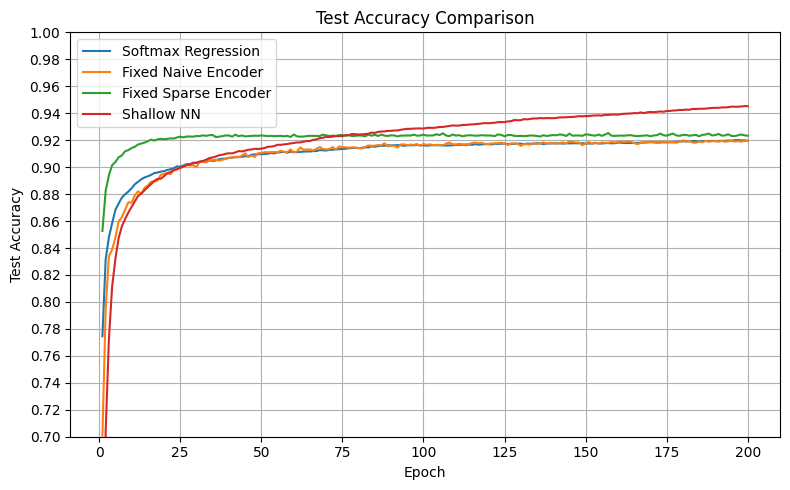

In [208]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(test_accuracies)+1), test_accuracies, label="Softmax Regression")
plt.plot(range(1, len(test_accuracies_naive)+1), test_accuracies_naive, label="Fixed Naive Encoder")
plt.plot(range(1, len(test_accuracies_sparse)+1), test_accuracies_sparse, label="Fixed Sparse Encoder")
plt.plot(range(1, len(test_accuracies_NN)+1), test_accuracies_NN, label="Shallow NN")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.ylim(0.7, 1.0)
plt.yticks(np.arange(0.7, 1.01, 0.02))
plt.tight_layout()
plt.show()

---

#### Question 4: Full BP on Both Layers

In [211]:
class PreInitFirstLayerNN(torch.nn.Module):
  def __init__(self, encoder_linear):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.encoder = torch.nn.Linear(28*28, 100)
    self.encoder.weight = torch.nn.Parameter(encoder_linear.weight.data.clone())
    self.encoder.bias = torch.nn.Parameter(encoder_linear.bias.data.clone())
    self.activation = torch.nn.Sigmoid()
    self.fc2 = torch.nn.Linear(100, 10)

  def forward(self, x):
    x = self.flatten(x)
    x = self.encoder(x)
    x = self.activation(x)
    x = self.fc2(x)
    return x

preinit_naive_nn = PreInitFirstLayerNN(naive_encoder_linear).to(device)
preinit_sparse_nn = PreInitFirstLayerNN(sparse_encoder_linear).to(device)

pn_optimizer = torch.optim.SGD(preinit_naive_nn.parameters(), lr=0.01)
ps_optimizer = torch.optim.SGD(preinit_sparse_nn.parameters(), lr=0.01)

In [213]:
test_accuracies_naive_PINN = []
test_accuracies_sparse_PINN = []

epochs = 200
for t in range(epochs):
  if t % 10 == 0:
    print(f"Epoch {t+1}")
  train(train_dataloader, preinit_naive_nn, loss_fn, pn_optimizer)
  acc = test(test_dataloader, preinit_naive_nn, loss_fn)
  test_accuracies_naive_PINN.append(acc)

  train(train_dataloader, preinit_sparse_nn, loss_fn, ps_optimizer)
  acc = test(test_dataloader, preinit_sparse_nn, loss_fn)
  test_accuracies_sparse_PINN.append(acc)

Epoch 1
Epoch 11
Epoch 21
Epoch 31
Epoch 41
Epoch 51
Epoch 61
Epoch 71
Epoch 81
Epoch 91
Epoch 101
Epoch 111
Epoch 121
Epoch 131
Epoch 141
Epoch 151
Epoch 161
Epoch 171
Epoch 181
Epoch 191


Plot which mimics the behavior of M02-S17 as the autoencoder versions all come up to around the same accuracy (at least above their original and above softmax) showing that the pre-initialization steps can be unnecessary if both layers are allowed to be trained

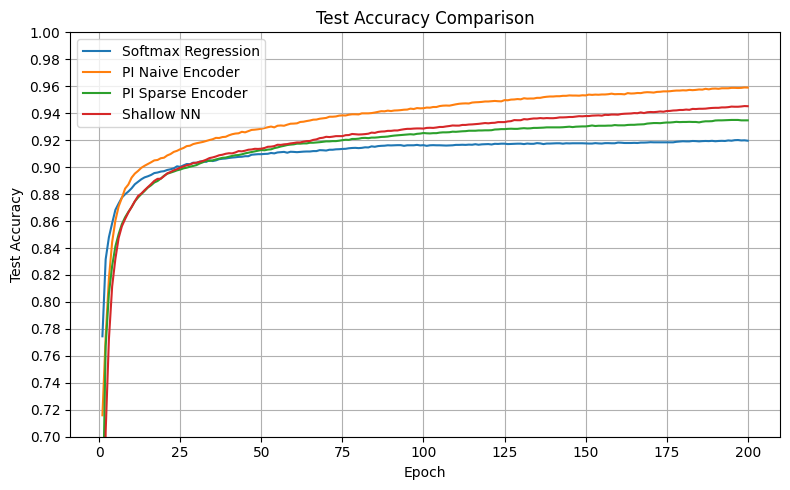

In [214]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(test_accuracies)+1), test_accuracies, label="Softmax Regression")
plt.plot(range(1, len(test_accuracies_naive)+1), test_accuracies_naive_PINN, label="PI Naive Encoder")
plt.plot(range(1, len(test_accuracies_sparse)+1), test_accuracies_sparse_PINN, label="PI Sparse Encoder")
plt.plot(range(1, len(test_accuracies_NN)+1), test_accuracies_NN, label="Shallow NN")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.ylim(0.7, 1.0)
plt.yticks(np.arange(0.7, 1.01, 0.02))
plt.tight_layout()
plt.show()